Выбранный датасет отображает конверсию пользователей в покупку после просмотра рекламы.

Далее подключаю необходимые библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

In [61]:
df_kag = pd.read_csv("KAG_conversion_data.csv", index_col="ad_id",)
print(df_kag.isnull().sum()) #проверяем наличие пропусков
df_kag


xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64


,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
ad_id,,,,,,,,,,
708746,916,103916,30-34,M,15,7350,1,1.430000,2,1
708749,916,103917,30-34,M,16,17861,2,1.820000,2,0
708771,916,103920,30-34,M,20,693,0,0.000000,1,0
708815,916,103928,30-34,M,28,4259,1,1.250000,1,0
708818,916,103928,30-34,M,28,4133,1,1.290000,1,1
...,...,...,...,...,...,...,...,...,...,...
1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2
1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0
1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0


# Выведем на экран количество показов рекламы по возрастным категориям

,Impressions
age,
30-34,67993019
35-39,42104644
40-44,39604307
45-49,63732858


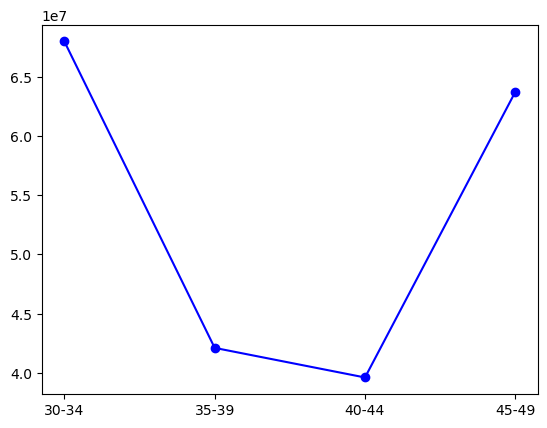

In [3]:
age_impressions = df_kag.pivot_table(values= ["Impressions"], index= df_kag.age, aggfunc="sum")

x = age_impressions.index
y = age_impressions.Impressions.values

plt.plot(x, y, marker='o', linestyle='-', color='b', label="Отношение количества показов к возрасту")
age_impressions

На графике видно падение показов рекламы на платформе (Facebook) с в промежутках 35-44 лет.

# Оценим количество кликов по рекламе в каждой возрастной группе.

,Clicks
age,
30-34,9483
35-39,7094
40-44,7736
45-49,13852


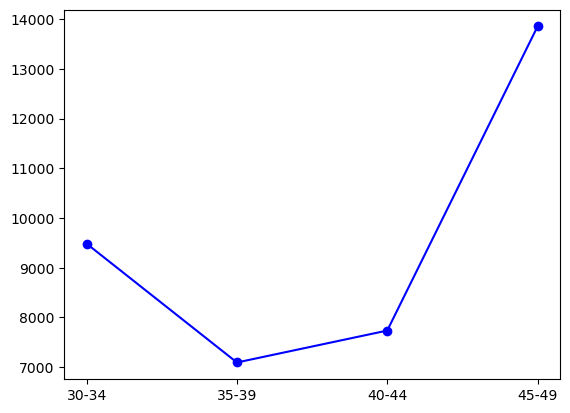

In [4]:
age_click = df_kag.pivot_table(values= ["Clicks"], index= df_kag.age, aggfunc="sum")

x = age_click.index
y = age_click.Clicks.values

plt.plot(x, y, marker='o', linestyle='-', color='b')
age_click

Большее количество показов рекламы молодой аудитории не оказало влияния на их интерес к продукту компании.
### Вывод: наибольший интерес к продукту показывает взрослая аудитория платформы.


Оценим конверсию аудитории просмотр - клик.

<Axes: xlabel='xyz_campaign_id'>

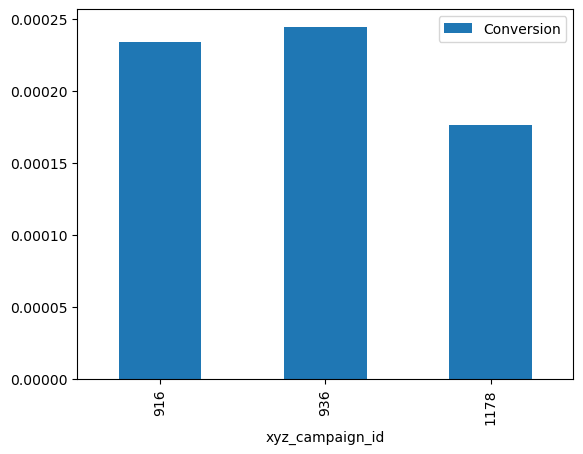

In [69]:
campaign_click = pd.pivot_table(df_kag, values=["Clicks", "Impressions"], index= df_kag["xyz_campaign_id"], aggfunc="sum")


campaign_click["Conversion"] = (campaign_click["Clicks"] / campaign_click["Impressions"])

x = campaign_click.index
y = campaign_click.Conversion

campaign_click[["Conversion"]].plot.bar()



Вывод, конверсия по кампании 1178 ниже по сравнию с остальными - стоит обратить внимание на сравнение её с иными кампаниями в различных плоскостях.